<a href="https://colab.research.google.com/github/srijakothakonda/creditcard_Fraud-detection/blob/main/creditcard_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k (6).csv
Dataset Shape: (10000, 10)
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1       

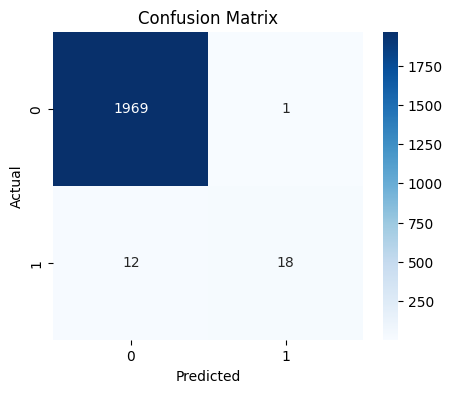

In [8]:
# =========================
# 1. Install Libraries
# =========================
!pip install pandas scikit-learn imbalanced-learn matplotlib seaborn

# =========================
# 2. Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 3. Upload Dataset in Colab
# =========================
from google.colab import files
uploaded = files.upload()  # choose your CSV file here

# Load the uploaded CSV
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# =========================
# 4. Explore Data
# =========================
print("Dataset Shape:", df.shape)
print(df.head())

# Check class distribution
print("\nClass Distribution:")
print(df['is_fraud'].value_counts())  # ✅ correct target column

# =========================
# 5. Split Features & Target
# =========================
X = df.drop('is_fraud', axis=1)  # ✅ correct target column
y = df['is_fraud']               # ✅ correct target column

# =========================
# 6. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# =========================
# 7. Handle Imbalance using SMOTE (with encoding)
# =========================
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    # One-Hot Encode categorical columns
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    X_train_cat = encoder.fit_transform(X_train[categorical_cols])
    X_test_cat = encoder.transform(X_test[categorical_cols])

    # Replace categorical columns with encoded columns
    X_train_numeric = np.hstack([X_train.drop(categorical_cols, axis=1).values, X_train_cat])
    X_test_numeric = np.hstack([X_test.drop(categorical_cols, axis=1).values, X_test_cat])
else:
    X_train_numeric = X_train.values
    X_test_numeric = X_test.values

# Apply SMOTE on numeric data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_numeric, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
# 8. Train Random Forest Model
# =========================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# =========================
# 9. Make Predictions
# =========================
y_pred = model.predict(X_test_numeric)  # instead of X_test

# =========================
# 10. Evaluation Metrics
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# =========================
# 11. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# =========================
# 12. Plot Confusion Matrix
# =========================
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()